<a href="https://colab.research.google.com/github/kaitlynle203/credit-card-fraud-detection/blob/main/Creditcard_Fraud_Dectection_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Data Acquisition


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


- Dataset: Credit Card Transactions  
- Total: ~284,000 transactions, 31 features  
- Time: Seconds elapsed between this transaction and the first transaction in the dataset (seconds).
- V1–V28: Principal Component Analysis (PCA) transformed features. These are anonymized transaction patterns (unitless).
- Amount: Transaction amount (Euros).
- Class: Target variable (0 = Normal transaction, 1 = Fraudulent transaction).

# 2. Data Preparation

In [ ]:
df.isnull().sum()


###  Missing Values

The dataset was checked for missing values using `df.isnull().sum()`.
No missing values were found. Therefore, no rows were removed and no imputation was required.

In [ ]:
df[df.isnull().any(axis=1)].shape

(0, 31)

In [ ]:
df.dtypes

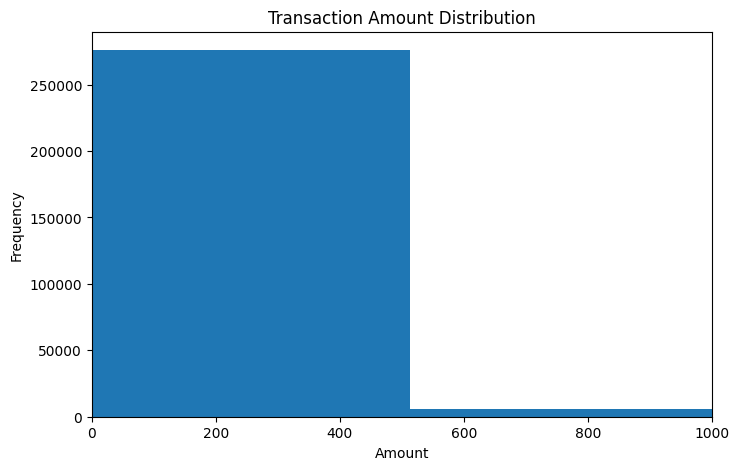

In [ ]:
df["Amount"].describe()
plt.figure(figsize=(8,5))
plt.hist(df["Amount"], bins=50)
plt.xlim(0, 1000)
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.title("Transaction Amount Distribution")
plt.show()

The transaction amount distribution is highly right-skewed. Most transactions involve small amounts, while a small number of transactions are significantly larger. These extreme values were retained because they may represent meaningful fraud-related behavior rather than data errors.

# 3. Exploratory Data Analysis (EDA)

In [ ]:
df["Class"].value_counts()

,count
Class,
0,284315
1,492


In [ ]:
df["Class"].value_counts(normalize=True) * 100

,proportion
Class,
0,99.827251
1,0.172749


## Univariate Analysis – Target Variable (Class)
The dataset is extremely imbalanced. Fraudulent transactions account for only 0.17% of all observations, while normal transactions represent 99.83%.
Due to this imbalance, accuracy alone would be misleading. Therefore, evaluation metrics such as precision, recall, and F1-score will be more appropriate when building the model.

In [ ]:
corr = df.corr()
corr["Class"].sort_values(ascending=False)

,Class
Class,1.000000
V11,0.154876
V4,0.133447
V2,0.091289
V21,0.040413
V19,0.034783
V20,0.020090
V8,0.019875
V27,0.017580
V28,0.009536


In [ ]:
df.groupby("Class")[["V12","V14","V17"]].mean()

,V12,V14,V17
Class,,,
0,0.010832,0.012064,0.011535
1,-6.259393,-6.971723,-6.665836


### Bivariate Analysis – Relationship with Fraud

- Features V12, V14, and V17 show the strongest relationships with fraud.
- The negative correlations indicate that fraudulent transactions tend to occur at lower values of these features.
- Transaction amount does not strongly correlate with fraud.
- This suggests fraud is driven more by complex patterns in PCA features rather than transaction size.

# 4. Feature Engineering/ Selection

- The dataset does not contain any categorical variables, as all features have already been transformed using PCA. Therefore, no additional encoding or transformation is required.

- From the exploratory data analysis, several features such as V12, V14, and V17 show stronger relationships with fraudulent transactions. These features may be more useful for detecting fraud compared to transaction amount.

- At this stage, all features are retained to avoid removing potentially useful information. More advanced feature selection techniques could be applied in the future to improve model performance and reduce noise.

##5. Modelling


In [ ]:
#split data
from sklearn.model_selection import train_test_split

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

The dataset was split into training and testing sets using an 80/20 ratio. This allows the model to be trained on one portion of the data and evaluated on unseen data to ensure generalization.

In [ ]:
#train model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=2000, class_weight='balanced')
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=2000)

Logistic Regression was used as the baseline model due to its simplicity and interpretability. The parameter class_weight='balanced' was applied to address the severe class imbalance in the dataset. A convergence warning appeared, indicating that the model may require further tuning or scaling for optimal performance.



In [ ]:
#predict
y_pred = model.predict(X_test)

In [ ]:
import pandas as pd

pd.DataFrame({
    "Actual": y_test.values[:17],
    "Predicted": y_pred[:17]
})

,Actual,Predicted
0,1,1
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


Some normal transactions were incorrectly classified as fraud (false positives).
This is expected due to class balancing, which prioritizes detecting fraud cases.
As a result, the model tends to flag more transactions as suspicious.

##6. Model Evaluation

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[55255  1609]
 [    6    92]]
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.05      0.94      0.10        98

    accuracy                           0.97     56962
   macro avg       0.53      0.96      0.54     56962
weighted avg       1.00      0.97      0.98     56962



- Accuracy is high (~97%), but this is misleading due to class imbalance  
- Recall for fraud is high → the model successfully detects most fraud cases  
- Precision for fraud is low → many false positives  
- The model prioritizes catching fraud over being precise

# 7. Technical Requirements

Reproducibility:
The notebook runs from top to bottom without errors. All preprocessing and analysis steps are executed sequentially to ensure reproducibility.

Library Usage:
Standard data science libraries including pandas, numpy, and matplotlib were used for data manipulation and visualization.

Comments & Narrative:
Markdown cells were included throughout the notebook to explain data cleaning decisions, exploratory analysis findings, and modeling considerations.